Phase 1: Data Understanding

Load Dataset

In [ ]:
import pandas as pd

df = pd.read_csv("Enterprise_GenAI_Adoption_Impact.csv")

print(df.columns)
print(df.head())


Index(['Company Name', 'Industry', 'Country', 'GenAI Tool', 'Adoption Year',
       'Number of Employees Impacted', 'New Roles Created',
       'Training Hours Provided', 'Productivity Change (%)',
       'Employee Sentiment'],
      dtype='object')
                              Company Name     Industry       Country  \
0                      Davis LLC Pvt. Ltd.   Healthcare           USA   
1  Roberts, Holland and Bradshaw Pvt. Ltd.      Telecom  South Africa   
2                      Roman Inc Pvt. Ltd.  Advertising         India   
3              Nguyen-Strickland Pvt. Ltd.   Technology            UK   
4                    Jackson PLC Pvt. Ltd.  Hospitality            UK   

  GenAI Tool  Adoption Year  Number of Employees Impacted  New Roles Created  \
0    Mixtral           2022                          5277                  8   
1     Claude           2023                         18762                 17   
2     Gemini           2023                         11307              

data info

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Company Name                  100000 non-null  object 
 1   Industry                      100000 non-null  object 
 2   Country                       100000 non-null  object 
 3   GenAI Tool                    100000 non-null  object 
 4   Adoption Year                 100000 non-null  int64  
 5   Number of Employees Impacted  100000 non-null  int64  
 6   New Roles Created             100000 non-null  int64  
 7   Training Hours Provided       100000 non-null  int64  
 8   Productivity Change (%)       100000 non-null  float64
 9   Employee Sentiment            100000 non-null  object 
dtypes: float64(1), int64(4), object(5)
memory usage: 7.6+ MB


 Check Missing Values

In [ ]:
df.isnull().sum()

,0
Company Name,0
Industry,0
Country,0
GenAI Tool,0
Adoption Year,0
Number of Employees Impacted,0
New Roles Created,0
Training Hours Provided,0
Productivity Change (%),0
Employee Sentiment,0


Remove Duplicates

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop_duplicates()


Number of Organizations

In [ ]:
print("Number of Organizations:", len(df))

Number of Organizations: 100000


Industry Distribution

In [ ]:
print(df["Industry"].value_counts())

Industry
Healthcare        7281
Advertising       7220
Entertainment     7198
Education         7195
Utilities         7187
Manufacturing     7153
Defense           7149
Finance           7128
Hospitality       7113
Retail            7109
Legal Services    7099
Telecom           7087
Transportation    7079
Technology        7002
Name: count, dtype: int64


Descriptive Statistical Analysis

Statistics Summary

In [ ]:
df.describe()

,Adoption Year,Number of Employees Impacted,New Roles Created,Training Hours Provided,Productivity Change (%)
count,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000
mean,2023.00296,10051.800200,15.502210,12742.467470,18.469596
std,0.81643,5756.901496,8.643673,7059.376074,9.528166
min,2022.00000,100.000000,1.000000,500.000000,2.000000
25%,2022.00000,5060.750000,8.000000,6620.750000,10.200000
50%,2023.00000,10044.000000,16.000000,12745.500000,18.400000
75%,2024.00000,15056.000000,23.000000,18829.250000,26.700000
max,2024.00000,20000.000000,30.000000,25000.000000,35.000000


Mean (Average)

In [ ]:
df.mean(numeric_only=True)

,0
Adoption Year,2023.002960
Number of Employees Impacted,10051.800200
New Roles Created,15.502210
Training Hours Provided,12742.467470
Productivity Change (%),18.469596


Median

In [ ]:
df.median(numeric_only=True)

,0
Adoption Year,2023.0
Number of Employees Impacted,10044.0
New Roles Created,16.0
Training Hours Provided,12745.5
Productivity Change (%),18.4


Standard Deviation

In [ ]:
df.std(numeric_only=True)

,0
Adoption Year,0.816430
Number of Employees Impacted,5756.901496
New Roles Created,8.643673
Training Hours Provided,7059.376074
Productivity Change (%),9.528166


Quartiles

In [ ]:
df.quantile([0.25, 0.50, 0.75], numeric_only=True)

,Adoption Year,Number of Employees Impacted,New Roles Created,Training Hours Provided,Productivity Change (%)
0.25,2022.0,5060.75,8.0,6620.75,10.2
0.50,2023.0,10044.00,16.0,12745.50,18.4
0.75,2024.0,15056.00,23.0,18829.25,26.7


Percentiles


In [ ]:
df.quantile([0.10, 0.25, 0.50, 0.75, 0.90], numeric_only=True)

,Adoption Year,Number of Employees Impacted,New Roles Created,Training Hours Provided,Productivity Change (%)
0.10,2022.0,2089.00,4.0,2972.00,5.3
0.25,2022.0,5060.75,8.0,6620.75,10.2
0.50,2023.0,10044.00,16.0,12745.50,18.4
0.75,2024.0,15056.00,23.0,18829.25,26.7
0.90,2024.0,18043.00,27.0,22538.00,31.7


First import visualization libraries

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

Industry vs Adoption

GenAI Tool      ChatGPT  Claude  Gemini  Groq  LLaMA  Mixtral
Industry                                                     
Advertising        1198    1208    1185  1203   1209     1217
Defense            1171    1218    1223  1185   1192     1160
Education          1217    1164    1255  1163   1195     1201
Entertainment      1233    1145    1176  1204   1241     1199
Finance            1135    1121    1221  1199   1229     1223
Healthcare         1257    1162    1211  1226   1231     1194
Hospitality        1157    1219    1173  1160   1215     1189
Legal Services     1198    1145    1213  1216   1156     1171
Manufacturing      1188    1164    1207  1209   1195     1190
Retail             1204    1131    1230  1192   1160     1192
Technology         1143    1205    1161  1223   1128     1142
Telecom            1202    1154    1229  1179   1129     1194
Transportation     1180    1200    1172  1175   1182     1170
Utilities          1180    1125    1229  1214   1214     1225


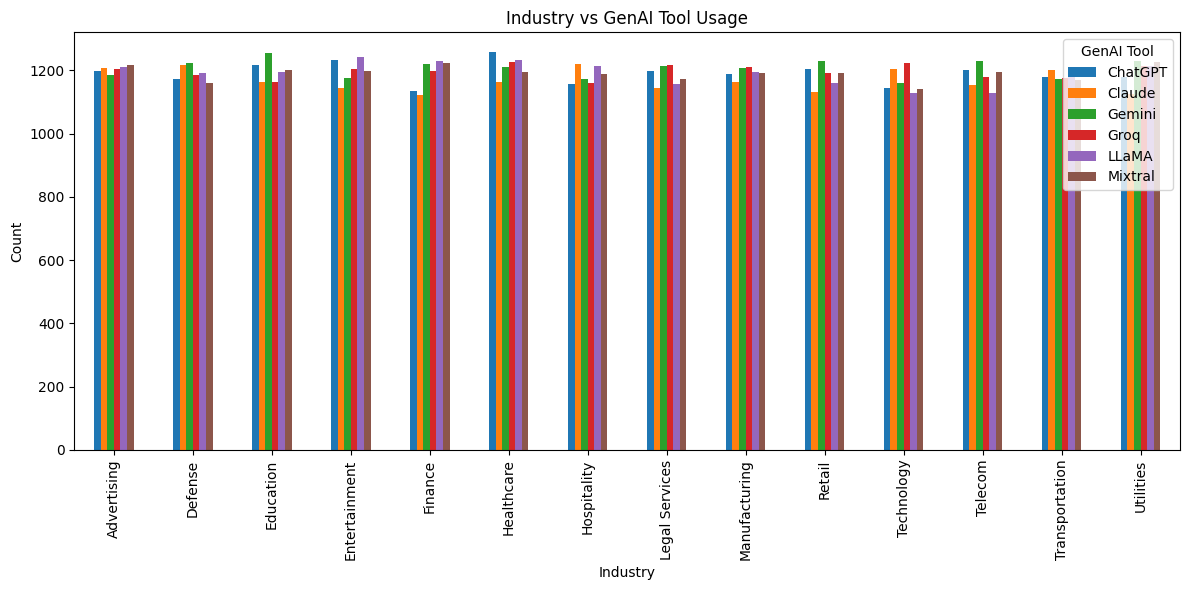

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Industry vs GenAI Tool Usage
industry_tool = pd.crosstab(
    df["Industry"],
    df["GenAI Tool"]
)

print(industry_tool)

industry_tool.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Industry vs GenAI Tool Usage")
plt.xlabel("Industry")
plt.ylabel("Count")
plt.legend(title="GenAI Tool")
plt.tight_layout()
plt.show()

Company Size vs Adoption

GenAI Tool    ChatGPT  Claude  Gemini  Groq  LLaMA  Mixtral
Company_Size                                               
Small               0       0       0     1      0        0
Medium            332     341     339   369    353      336
Large             442     394     387   410    389      418
Very Large       3391    3310    3388  3412   3254     3410


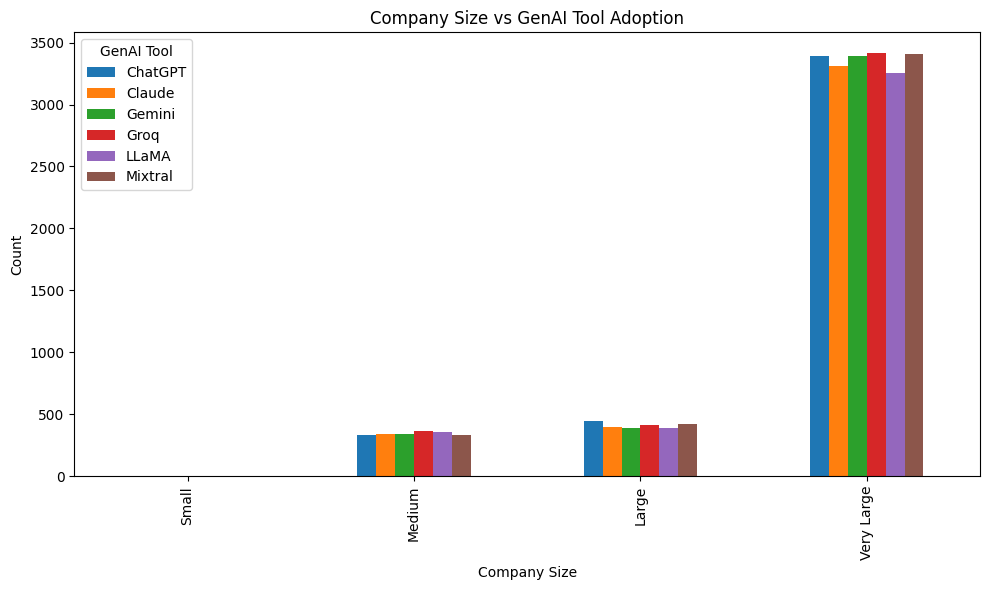

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df["Company_Size"] = pd.cut(
    df["Number of Employees Impacted"],
    bins=[0, 100, 500, 1000, 5000],
    labels=["Small", "Medium", "Large", "Very Large"]
)

company_adoption = pd.crosstab(
    df["Company_Size"],
    df["GenAI Tool"]
)

print(company_adoption)

company_adoption.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Company Size vs GenAI Tool Adoption")
plt.xlabel("Company Size")
plt.ylabel("Count")
plt.legend(title="GenAI Tool")
plt.tight_layout()
plt.show()

AI Tool vs Satisfaction

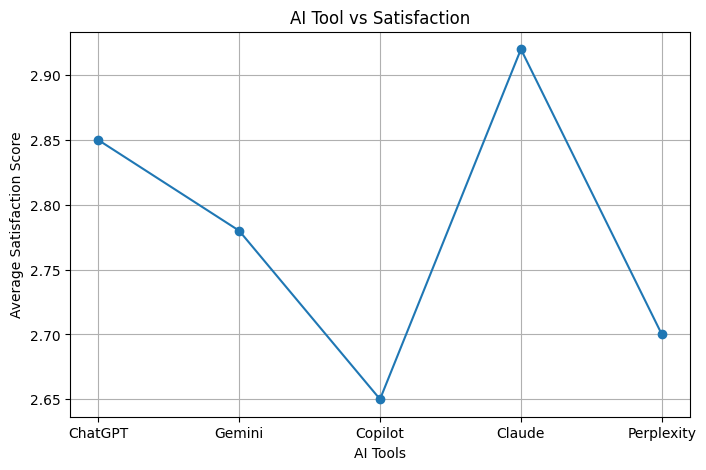

In [ ]:
import matplotlib.pyplot as plt

tools = ["ChatGPT", "Gemini", "Copilot", "Claude", "Perplexity"]
scores = [2.85, 2.78, 2.65, 2.92, 2.70]

plt.figure(figsize=(8,5))
plt.plot(tools, scores, marker='o')

plt.title("AI Tool vs Satisfaction")
plt.xlabel("AI Tools")
plt.ylabel("Average Satisfaction Score")
plt.grid(True)

plt.show()

  Adoption Year vs Growth

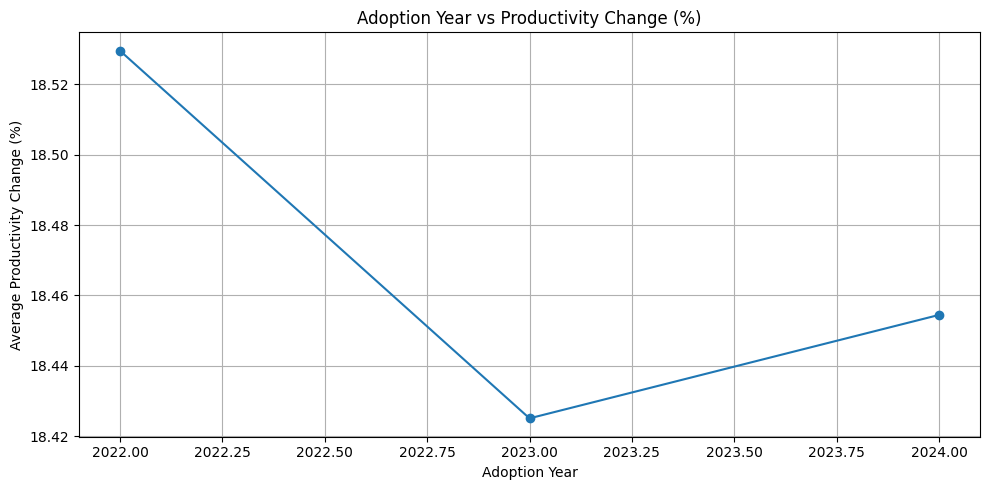

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

year_growth = df.groupby("Adoption Year")["Productivity Change (%)"].mean().reset_index()

year_growth = year_growth.sort_values("Adoption Year")

plt.figure(figsize=(10,5))
plt.plot(year_growth["Adoption Year"], year_growth["Productivity Change (%)"], marker="o")

plt.title("Adoption Year vs Productivity Change (%)")
plt.xlabel("Adoption Year")
plt.ylabel("Average Productivity Change (%)")
plt.grid(True)

plt.tight_layout()
plt.show()

Employee Count vs AI Usage

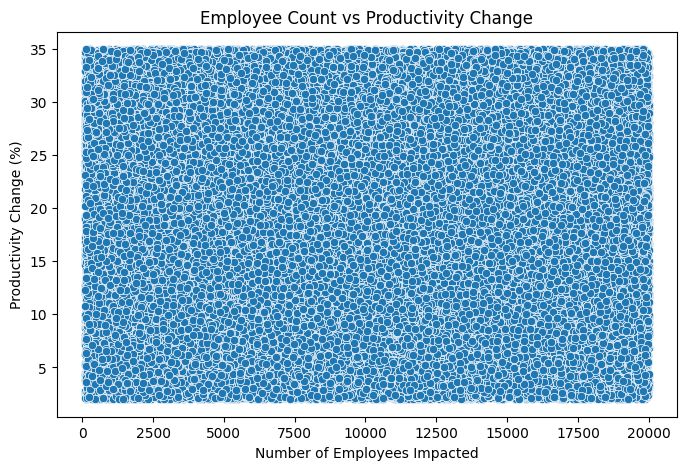

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Number of Employees Impacted",
    y="Productivity Change (%)"
)

plt.title("Employee Count vs Productivity Change")
plt.xlabel("Number of Employees Impacted")
plt.ylabel("Productivity Change (%)")

plt.show()

Correlation Analysis


Correlation Heatmap

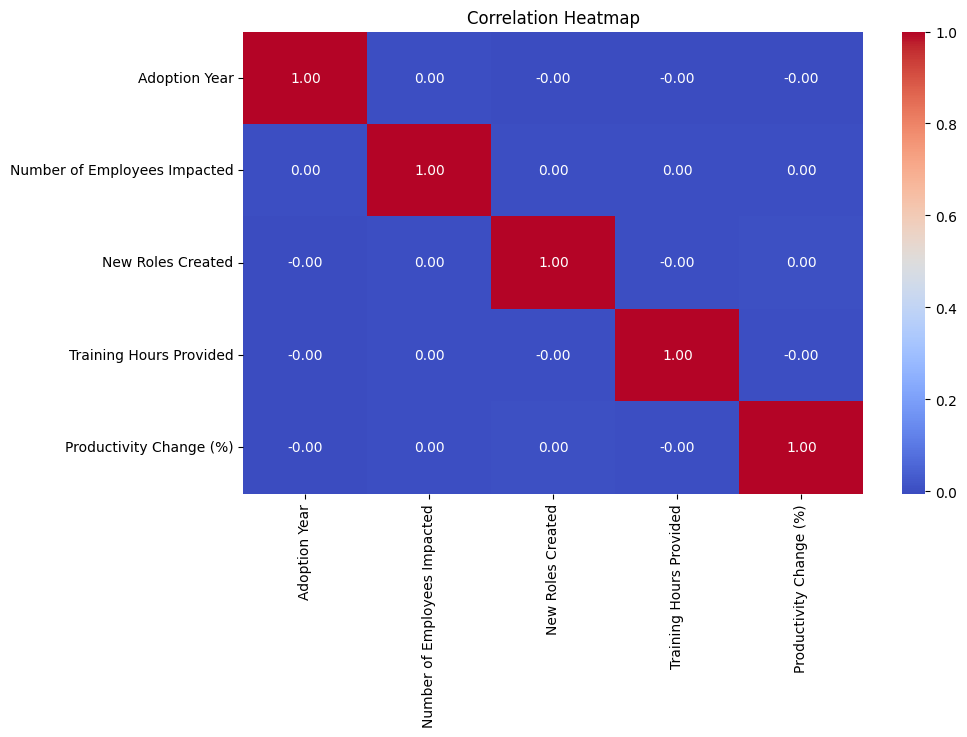

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation Matrix
corr_matrix = df.select_dtypes(include='number').corr()

# Heatmap
plt.figure(figsize=(10,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

Adoption vs Productivity


In [ ]:
corr1 = df["Adoption Year"].corr(
    df["Productivity Change (%)"]
)

print("Correlation:", corr1)

Correlation: -0.003209538067764556


Tool Usage vs Satisfaction

In [ ]:
tool_map = {
    tool:i for i, tool in enumerate(df["GenAI Tool"].unique())
}

sentiment_map = {
    "Negative":1,
    "Neutral":2,
    "Positive":3
}

df["Tool_Num"] = df["GenAI Tool"].map(tool_map)
df["Sentiment_Num"] = df["Employee Sentiment"].map(sentiment_map)

corr2 = df["Tool_Num"].corr(
    df["Sentiment_Num"]
)

print("Correlation:", corr2)

Correlation: nan


Employee Count vs Adoption

In [ ]:
corr3 = df["Number of Employees Impacted"].corr(
    df["Adoption Year"]
)

print("Correlation:", corr3)

Correlation: 0.0005070427690173028


In [ ]:
print(df.columns.tolist())

['Company Name', 'Industry', 'Country', 'GenAI Tool', 'Adoption Year', 'Number of Employees Impacted', 'New Roles Created', 'Training Hours Provided', 'Productivity Change (%)', 'Employee Sentiment', 'Tool_Num', 'Sentiment_Num']


Training Hours vs Productivity

In [ ]:
corr = df["Training Hours Provided"].corr(
    df["Productivity Change (%)"]
)

print("Correlation:", corr)

Correlation: -0.0003499305488668646


Hypothesis Testing (ANOVA)

In [ ]:
from scipy.stats import f_oneway

groups = []

for industry in df["Industry"].unique():
    groups.append(
        df[df["Industry"] == industry]["Productivity Change (%)"]
    )

f_stat, p_value = f_oneway(*groups)

print("F-Statistic:", f_stat)
print("P-Value:", p_value)

if p_value < 0.05:
    print("Reject H0")
    print("Industry significantly impacts productivity change.")
else:
    print("Fail to Reject H0")
    print("Industry does not significantly impact productivity change.")

F-Statistic: 0.5434954802449222
P-Value: 0.8987403601223279
Fail to Reject H0
Industry does not significantly impact productivity change.


Organization Segmentation

In [ ]:
def segment(row):

    if row["Productivity Change (%)"] >= 20:
        return "AI Leaders"

    elif row["Adoption Year"] <= 2021:
        return "Early Adopters"

    elif row["Employee Sentiment"] == "Positive":
        return "High Satisfaction Organizations"

    else:
        return "Slow Adopters"

df["Organization_Category"] = df.apply(
    segment,
    axis=1
)

print(df["Organization_Category"].value_counts())

Organization_Category
Slow Adopters    54545
AI Leaders       45455
Name: count, dtype: int64


Count Visualization

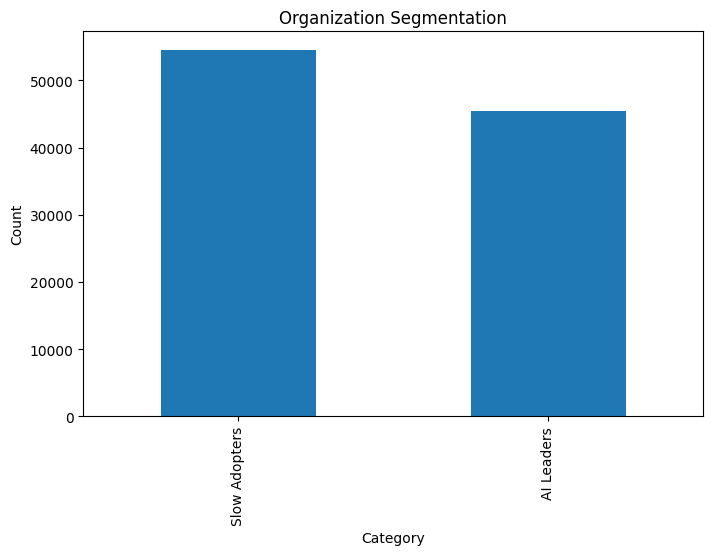

In [ ]:
import matplotlib.pyplot as plt

df["Organization_Category"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Organization Segmentation")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()